# **Brain Tumor Segmentation using U-Net**

## **Importing Libraries**

In [ ]:
import os
import zipfile
import random
import shutil
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("GPU Available:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### **Reproducibility**

A fixed random seed is used where possible so that dataset splitting, initialization, and experiments are more reproducible.

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## **Extracting the Segmentation Dataset**

In [ ]:
zip_path = "/content/brain_tumor_segmentation.zip"
extract_path = "/content/segmentation_raw"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


### **Defining the Image & Mask Directories**

In [ ]:
images_dir = "/content/segmentation_raw/Brain Tumor/images"
masks_dir = "/content/segmentation_raw/Brain Tumor/masks"

print("Images directory:", images_dir)
print("Masks directory:", masks_dir)

Images directory: /content/segmentation_raw/Brain Tumor/images
Masks directory: /content/segmentation_raw/Brain Tumor/masks


### **Verifying Image & Mask Pairs**

In [ ]:
image_files = sorted([
    f for f in os.listdir(images_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

mask_files = sorted([
    f for f in os.listdir(masks_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

Number of images: 3063
Number of masks: 3063


In [ ]:
image_names = {os.path.splitext(f)[0] for f in image_files}
mask_names = {os.path.splitext(f)[0] for f in mask_files}

print("Images without masks:", image_names - mask_names)
print("Masks without images:", mask_names - image_names)

Images without masks: set()
Masks without images: set()


## **Defining the Preprocessing Configuration**

To maintain consistency between the classification and segmentation stages, MRI images will be converted to grayscale and resized to 224×224 pixels. Pixel values will be normalized to the range [0, 1] when loaded for model training. Masks will also be resized to 224×224, but will be converted to binary values representing background and tumor regions.

In [ ]:
IMG_SIZE = (224, 224)

print("Image size:", IMG_SIZE)
print("Image color mode: Grayscale")
print("Image normalization: pixel / 255.0")
print("Mask format: Binary {0, 1}")

Image size: (224, 224)
Image color mode: Grayscale
Image normalization: pixel / 255.0
Mask format: Binary {0, 1}


### **Creating the Processed Dataset Directories**

In [ ]:
processed_dir = "/content/processed_segmentation"

processed_images_dir = os.path.join(processed_dir, "images")
processed_masks_dir = os.path.join(processed_dir, "masks")

os.makedirs(processed_images_dir, exist_ok=True)
os.makedirs(processed_masks_dir, exist_ok=True)

print("Processed dataset directories created.")

Processed dataset directories created.


### **Defining the Preprocessing Functions**

In [ ]:
def preprocess_mri(image_path, output_path):
    # Read image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        return False

    # Resize MRI
    image = cv2.resize(
        image,
        IMG_SIZE,
        interpolation=cv2.INTER_AREA
    )

    # Save as PNG
    cv2.imwrite(output_path, image)

    return True


def preprocess_mask(mask_path, output_path):
    # Read mask as grayscale
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if mask is None:
        return False

    # Resize using nearest-neighbor interpolation
    mask = cv2.resize(
        mask,
        IMG_SIZE,
        interpolation=cv2.INTER_NEAREST
    )

    # Convert to binary mask
    _, mask = cv2.threshold(
        mask,
        127,
        255,
        cv2.THRESH_BINARY
    )

    # Save as PNG
    cv2.imwrite(output_path, mask)

    return True

### **Processing All MRI Images & Their Corresponding Masks**

In [ ]:
processed_count = 0
failed_count = 0

for filename in image_files:

    image_path = os.path.join(images_dir, filename)
    mask_path = os.path.join(masks_dir, filename)

    output_image_path = os.path.join(
        processed_images_dir,
        filename
    )

    output_mask_path = os.path.join(
        processed_masks_dir,
        filename
    )

    image_success = preprocess_mri(
        image_path,
        output_image_path
    )

    mask_success = preprocess_mask(
        mask_path,
        output_mask_path
    )

    if image_success and mask_success:
        processed_count += 1
    else:
        failed_count += 1

print("Successfully processed:", processed_count)
print("Failed:", failed_count)

Successfully processed: 3063
Failed: 0


### **Verifying the Processed Dataset**

In [ ]:
processed_image_files = sorted([
    f for f in os.listdir(processed_images_dir)
    if f.lower().endswith(".png")
])

processed_mask_files = sorted([
    f for f in os.listdir(processed_masks_dir)
    if f.lower().endswith(".png")
])

print("Processed images:", len(processed_image_files))
print("Processed masks:", len(processed_mask_files))

Processed images: 3063
Processed masks: 3063


In [ ]:
processed_image_names = {
    os.path.splitext(f)[0]
    for f in processed_image_files
}

processed_mask_names = {
    os.path.splitext(f)[0]
    for f in processed_mask_files
}

print("Images without masks:", processed_image_names - processed_mask_names)
print("Masks without images:", processed_mask_names - processed_image_names)

Images without masks: set()
Masks without images: set()


### **Checking Image Dimensions & Mask Values**

In [ ]:
sample_name = processed_image_files[0]

sample_image = cv2.imread(
    os.path.join(processed_images_dir, sample_name),
    cv2.IMREAD_GRAYSCALE
)

sample_mask = cv2.imread(
    os.path.join(processed_masks_dir, sample_name),
    cv2.IMREAD_GRAYSCALE
)

print("Image shape:", sample_image.shape)
print("Mask shape:", sample_mask.shape)

print("Unique mask values:", np.unique(sample_mask))

Image shape: (224, 224)
Mask shape: (224, 224)
Unique mask values: [  0 255]


### **Visual Verification of MRI & Mask Pairs**

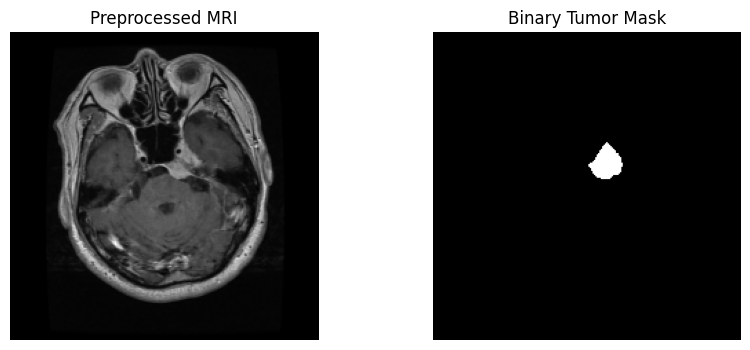

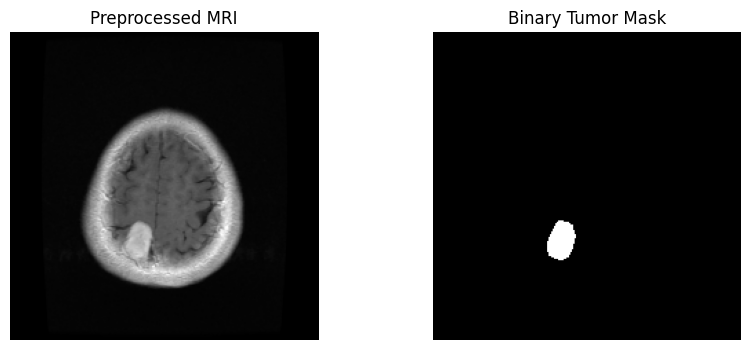

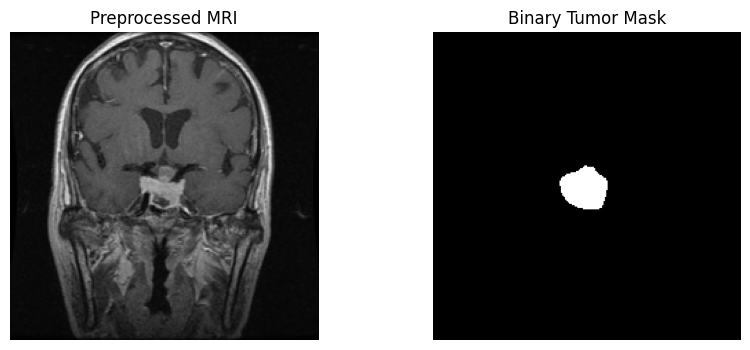

In [ ]:
sample_files = random.sample(processed_image_files, 3)

for filename in sample_files:

    image = cv2.imread(
        os.path.join(processed_images_dir, filename),
        cv2.IMREAD_GRAYSCALE
    )

    mask = cv2.imread(
        os.path.join(processed_masks_dir, filename),
        cv2.IMREAD_GRAYSCALE
    )

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Preprocessed MRI")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Binary Tumor Mask")
    plt.axis("off")

    plt.show()

## **Splitting the Segmentation Dataset**

In [ ]:
# Create paired filenames

paired_files = sorted(
    list(
        processed_image_names.intersection(processed_mask_names)
    )
)

print("Total paired samples:", len(paired_files))

Total paired samples: 3063


In [ ]:
train_files, temp_files = train_test_split(
    paired_files,
    test_size=0.30,
    random_state=SEED
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=SEED
)

print("Training samples:", len(train_files))
print("Validation samples:", len(val_files))
print("Test samples:", len(test_files))

Training samples: 2144
Validation samples: 459
Test samples: 460


### **Checking for Data Leakage**

In [ ]:
train_set = set(train_files)
val_set = set(val_files)
test_set = set(test_files)

print("Train ∩ Validation:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Validation ∩ Test:", len(val_set & test_set))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


## **Creating Paired Augmentation for MRI Images & Masks**

In [ ]:
def augment_pair(image, mask):

    # Random horizontal flip
    if random.random() < 0.5:
        image = cv2.flip(image, 1)
        mask = cv2.flip(mask, 1)

    # Random rotation
    angle = random.uniform(-10, 10)

    height, width = image.shape[:2]
    center = (width // 2, height // 2)

    rotation_matrix = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    image = cv2.warpAffine(
        image,
        rotation_matrix,
        (width, height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT
    )

    mask = cv2.warpAffine(
        mask,
        rotation_matrix,
        (width, height),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    # Random zoom
    if random.random() < 0.5:

        scale = random.uniform(0.9, 1.1)

        new_width = int(width * scale)
        new_height = int(height * scale)

        image = cv2.resize(
            image,
            (new_width, new_height),
            interpolation=cv2.INTER_LINEAR
        )

        mask = cv2.resize(
            mask,
            (new_width, new_height),
            interpolation=cv2.INTER_NEAREST
        )

        # Resize back to target dimensions
        image = cv2.resize(
            image,
            (width, height),
            interpolation=cv2.INTER_LINEAR
        )

        mask = cv2.resize(
            mask,
            (width, height),
            interpolation=cv2.INTER_NEAREST
        )

    # Ensure mask remains binary
    _, mask = cv2.threshold(
        mask,
        127,
        255,
        cv2.THRESH_BINARY
    )

    return image, mask

### **Visual Verification of Paired Augmentation**

In [ ]:
sample_file = random.choice(train_files)

image_path = os.path.join(
    processed_images_dir,
    sample_file + '.png'
)

mask_path = os.path.join(
    processed_masks_dir,
    sample_file + '.png'
)

image = cv2.imread(
    image_path,
    cv2.IMREAD_GRAYSCALE
)

mask = cv2.imread(
    mask_path,
    cv2.IMREAD_GRAYSCALE
)

aug_image, aug_mask = augment_pair(
    image.copy(),
    mask.copy()
)

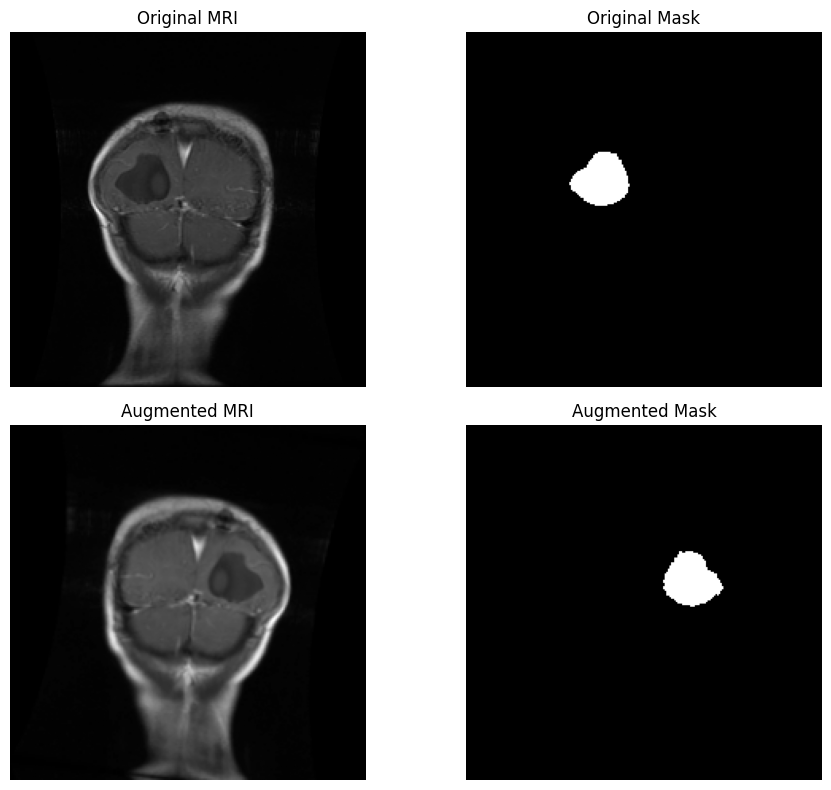

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original MRI")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Original Mask")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(aug_image, cmap="gray")
plt.title("Augmented MRI")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(aug_mask, cmap="gray")
plt.title("Augmented Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

## **Building the U-Net Segmentation Model**

### **Defining the Convolutional Block**

In [ ]:
def conv_block(x, filters):

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    return x

### **Building the Encoder**

In [ ]:
inputs = layers.Input(
    shape=(224, 224, 1),
    name="input_image"
)

# Encoder Block 1
c1 = conv_block(inputs, 32)
p1 = layers.MaxPooling2D(pool_size=(2, 2))(c1)


# Encoder Block 2
c2 = conv_block(p1, 64)
p2 = layers.MaxPooling2D(pool_size=(2, 2))(c2)


# Encoder Block 3
c3 = conv_block(p2, 128)
p3 = layers.MaxPooling2D(pool_size=(2, 2))(c3)


# Encoder Block 4
c4 = conv_block(p3, 256)
p4 = layers.MaxPooling2D(pool_size=(2, 2))(c4)

### **Building the Bottleneck**

In [ ]:
bottleneck = conv_block(p4, 512)

### **Building the Decoder**

In [ ]:
# Decoder Block 1
u1 = layers.Conv2DTranspose(
    256,
    kernel_size=2,
    strides=2,
    padding="same"
)(bottleneck)

u1 = layers.Concatenate()([u1, c4])
c5 = conv_block(u1, 256)

# Decoder Block 2
u2 = layers.Conv2DTranspose(
    128,
    kernel_size=2,
    strides=2,
    padding="same"
)(c5)

u2 = layers.Concatenate()([u2, c3])
c6 = conv_block(u2, 128)


# Decoder Block 3
u3 = layers.Conv2DTranspose(
    64,
    kernel_size=2,
    strides=2,
    padding="same"
)(c6)

u3 = layers.Concatenate()([u3, c2])
c7 = conv_block(u3, 64)


# Decoder Block 4
u4 = layers.Conv2DTranspose(
    32,
    kernel_size=2,
    strides=2,
    padding="same"
)(c7)

u4 = layers.Concatenate()([u4, c1])
c8 = conv_block(u4, 32)

### **Creating the Output Layer**

In [ ]:
outputs = layers.Conv2D(
    1,
    kernel_size=1,
    activation="sigmoid",
    name="tumor_mask"
)(c8)

### **Creating the Complete U-Net Model**

In [ ]:
unet = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="Brain_Tumor_U_Net"
)

In [ ]:
unet.summary()

Model: "Brain_Tumor_U_Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        320 │ input_image[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 224, 224,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_4[0][0]  

 Total params: 7,771,297 (29.65 MB)

 Trainable params: 7,765,409 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [ ]:
print("Input shape :", unet.input_shape)
print("Output shape:", unet.output_shape)

Input shape : (None, 224, 224, 1)
Output shape: (None, 224, 224, 1)


### **Dice Coefficient for Measuring Tumor Mask Overlap**

In [ ]:
def dice_coefficient(y_true, y_pred):
    smooth = 1e-6

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    dice = (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) +
        tf.reduce_sum(y_pred_f) +
        smooth
    )

    return dice

### **Dice Loss for Optimizing Tumor-Region Overlap**

In [ ]:
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

### **Combining Binary Cross-Entropy and Dice Loss**

In [ ]:
bce = tf.keras.losses.BinaryCrossentropy()


def combined_loss(y_true, y_pred):
    bce_loss = bce(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)

    return bce_loss + dice

### **Intersection over Union (IoU) for Segmentation Evaluation**

In [ ]:
def iou_score(y_true, y_pred):
    smooth = 1e-6

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    union = (
        tf.reduce_sum(y_true_f) +
        tf.reduce_sum(y_pred_f) -
        intersection
    )

    iou = (intersection + smooth) / (union + smooth)

    return iou

## **Creating TensorFlow Datasets for Training, Validation & Testing**

In [ ]:
BATCH_SIZE = 16

print("Batch size:", BATCH_SIZE)
print("Input shape: (224, 224, 1)")
print("Mask shape: (224, 224, 1)")

Batch size: 16
Input shape: (224, 224, 1)
Mask shape: (224, 224, 1)


### **Defining the MRI & Mask Loading Function**

In [ ]:
def load_image_mask(filename):

    image_path = os.path.join(
        processed_images_dir,
        filename + ".png"
    )

    mask_path = os.path.join(
        processed_masks_dir,
        filename + ".png"
    )

    # Read MRI as grayscale
    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    # Read mask as grayscale
    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    # Convert to float32
    image = image.astype(np.float32)
    mask = mask.astype(np.float32)

    # Normalize MRI to [0, 1]
    image = image / 255.0

    # Convert mask from {0, 255} to {0, 1}
    mask = mask / 255.0

    # Add channel dimension
    image = np.expand_dims(image, axis=-1)
    mask = np.expand_dims(mask, axis=-1)

    return image, mask

### **Verifying the Dataset Loading Function**

In [ ]:
sample_image, sample_mask = load_image_mask(train_files[0])

print("Image shape:", sample_image.shape)
print("Mask shape:", sample_mask.shape)

print("Image dtype:", sample_image.dtype)
print("Mask dtype:", sample_mask.dtype)

print(
    "Image range:",
    sample_image.min(),
    "to",
    sample_image.max()
)

print(
    "Mask values:",
    np.unique(sample_mask)
)

Image shape: (224, 224, 1)
Mask shape: (224, 224, 1)
Image dtype: float32
Mask dtype: float32
Image range: 0.0 to 0.9490196
Mask values: [0. 1.]


## **Creating Training, Validation & Test Datasets**

In [ ]:
def create_dataset(file_list):

    images = []
    masks = []

    for filename in file_list:

        image, mask = load_image_mask(filename)

        images.append(image)
        masks.append(mask)

    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (images, masks)
    )

    return dataset

In [ ]:
train_dataset = create_dataset(train_files)
val_dataset = create_dataset(val_files)
test_dataset = create_dataset(test_files)

### **Shuffling, Batching & Prefetching the Datasets**

In [ ]:
train_dataset = (
    train_dataset
    .shuffle(
        buffer_size=len(train_files),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

### **Verifying Dataset Shapes & Batching**

In [ ]:
train_batch_images, train_batch_masks = next(iter(train_dataset))
val_batch_images, val_batch_masks = next(iter(val_dataset))
test_batch_images, test_batch_masks = next(iter(test_dataset))

print("Training batch:")
print("Images:", train_batch_images.shape)
print("Masks :", train_batch_masks.shape)

print("\nValidation batch:")
print("Images:", val_batch_images.shape)
print("Masks :", val_batch_masks.shape)

print("\nTest batch:")
print("Images:", test_batch_images.shape)
print("Masks :", test_batch_masks.shape)

Training batch:
Images: (16, 224, 224, 1)
Masks : (16, 224, 224, 1)

Validation batch:
Images: (16, 224, 224, 1)
Masks : (16, 224, 224, 1)

Test batch:
Images: (16, 224, 224, 1)
Masks : (16, 224, 224, 1)


## **Applying Paired Augmentation to the Training Dataset**

In [ ]:
def augment_training_pair(image, mask):
    """
    Apply the existing paired augmentation function
    to one MRI image and its corresponding mask.
    """

    image, mask = augment_pair(image, mask)

    # Ensure expected dtype
    image = tf.cast(image, tf.float32)
    mask = tf.cast(mask, tf.float32)

    # Keep MRI in [0, 1]
    image = tf.clip_by_value(image, 0.0, 1.0)

    # Keep mask binary
    mask = tf.cast(mask > 0.5, tf.float32)

    return image, mask

In [ ]:
def augment_training_pair(image, mask):
    """
    Apply the existing paired augmentation function
    to one MRI image and its corresponding mask.
    """

    def _augment_wrapper(image_tensor, mask_tensor):
        # Convert tf.Tensor to numpy arrays for OpenCV operations
        image_np = image_tensor.numpy()
        mask_np = mask_tensor.numpy()

        # Remove the channel dimension (H, W, 1) -> (H, W) for OpenCV
        image_np_2d = np.squeeze(image_np, axis=-1)
        mask_np_2d = np.squeeze(mask_np, axis=-1)

        # Convert to uint8 [0, 255] for augment_pair (OpenCV)
        image_np_uint8 = (image_np_2d * 255).astype(np.uint8)
        mask_np_uint8 = (mask_np_2d * 255).astype(np.uint8)

        # Call the original augment_pair function which now receives 2D arrays
        aug_image_np_2d, aug_mask_np_2d = augment_pair(image_np_uint8, mask_np_uint8)

        # Convert back to float32 [0, 1] and add channel dimension for TensorFlow
        aug_image_tf = np.expand_dims(aug_image_np_2d.astype(np.float32) / 255.0, axis=-1)
        aug_mask_tf = np.expand_dims(aug_mask_np_2d.astype(np.float32) / 255.0, axis=-1)

        return aug_image_tf, aug_mask_tf

    # Use tf.py_function to execute the NumPy-based augmentation
    aug_image, aug_mask = tf.py_function(
        func=_augment_wrapper,
        inp=[image, mask],
        Tout=[tf.float32, tf.float32]
    )

    # tf.py_function loses the static shape information, so set it manually
    # The expected shape is (IMG_SIZE[0], IMG_SIZE[1], 1)
    aug_image.set_shape(image.shape)
    aug_mask.set_shape(mask.shape)

    # Keep MRI in [0, 1]
    aug_image = tf.clip_by_value(aug_image, 0.0, 1.0)

    # Keep mask binary (from {0, 1} after division by 255.0 in _augment_wrapper)
    # Ensure it's strictly binary {0.0, 1.0}
    aug_mask = tf.cast(aug_mask > 0.5, tf.float32)

    return aug_image, aug_mask

train_dataset_augmented = train_dataset.map(
    augment_training_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset_augmented = train_dataset_augmented.prefetch(
    tf.data.AUTOTUNE
)


### **Verifying the Augmented Training Dataset**

In [ ]:
aug_images, aug_masks = next(iter(train_dataset_augmented))

print("Augmented images shape:", aug_images.shape)
print("Augmented masks shape :", aug_masks.shape)

print("Image dtype:", aug_images.dtype)
print("Mask dtype :", aug_masks.dtype)

print(
    "Image range:",
    float(tf.reduce_min(aug_images)),
    "to",
    float(tf.reduce_max(aug_images))
)

print(
    "Mask unique values:",
    np.unique(aug_masks.numpy())
)

Augmented images shape: (16, 224, 224, 1)
Augmented masks shape : (16, 224, 224, 1)
Image dtype: <dtype: 'float32'>
Mask dtype : <dtype: 'float32'>
Image range: 0.0 to 0.9254902005195618
Mask unique values: [0. 1.]


## **Configuring Training Callbacks**

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
csv_logger = tf.keras.callbacks.CSVLogger(
    "/content/unet_training_history.csv",
    append=False
)

## **Compiling the U-Net**

In [ ]:
unet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=combined_loss,
    metrics=[
        dice_coefficient,
        iou_score
    ]
)

### **Final Training Pipeline Sanity Check**

In [ ]:
print("Training dataset:")
print(next(iter(train_dataset_augmented))[0].shape)
print(next(iter(train_dataset_augmented))[1].shape)

print("\nValidation dataset:")
print(next(iter(val_dataset))[0].shape)
print(next(iter(val_dataset))[1].shape)

print("\nTest dataset:")
print(next(iter(test_dataset))[0].shape)
print(next(iter(test_dataset))[1].shape)

Training dataset:
(16, 224, 224, 1)
(16, 224, 224, 1)

Validation dataset:
(16, 224, 224, 1)
(16, 224, 224, 1)

Test dataset:
(16, 224, 224, 1)
(16, 224, 224, 1)


## **Training the U-Net**

In [ ]:
EPOCHS = 50

history = unet.fit(
    train_dataset_augmented,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr,
        csv_logger
    ],
    verbose=1
)

Epoch 1/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 102s 409ms/step - dice_coefficient: 0.1159 - iou_score: 0.0625 - loss: 0.9894 - val_dice_coefficient: 0.0529 - val_iou_score: 0.0272 - val_loss: 10.6896 - learning_rate: 0.0010
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 42s 313ms/step - dice_coefficient: 0.2128 - iou_score: 0.1209 - loss: 0.8610 - val_dice_coefficient: 0.1131 - val_iou_score: 0.0602 - val_loss: 1.5102 - learning_rate: 0.0010
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 43s 319ms/step - dice_coefficient: 0.2370 - iou_score: 0.1373 - loss: 0.8402 - val_dice_coefficient: 0.0994 - val_iou_score: 0.0525 - val_loss: 1.7173 - learning_rate: 0.0010
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 43s 318ms/step - dice_coefficient: 0.2705 - iou_score: 0.1598 - loss: 0.8060 - val_dice_coefficient: 0.1441 - val_iou_score: 0.0782 - val_loss: 0.9694 - learning_rate: 0.0010
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 42s 316ms/step - dice_coefficient: 0.2553 - iou_score: 0.1493 - loss: 0.8226 - val_dice_coefficien

### **Summary**
The baseline U-Net achieved a best validation Dice coefficient of approximately 0.668
and a validation IoU score of approximately 0.504.


## **Residual U-Net**
To improve segmentation performance, we will now implement a Residual U-Net.

### **Residual Convolutional Block**

In [ ]:
def residual_block(x, filters, name):
    """
    Residual convolutional block.

    Two Conv2D + BatchNormalization layers are used in the main path.
    A 1x1 convolution is used in the shortcut when channel dimensions differ.
    """

    shortcut = x

    # Main path
    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name=f"{name}_conv1"
    )(x)

    x = layers.BatchNormalization(
        name=f"{name}_bn1"
    )(x)

    x = layers.Activation(
        "relu",
        name=f"{name}_relu1"
    )(x)

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name=f"{name}_conv2"
    )(x)

    x = layers.BatchNormalization(
        name=f"{name}_bn2"
    )(x)

    # Shortcut projection if required
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters,
            kernel_size=1,
            padding="same",
            use_bias=False,
            name=f"{name}_shortcut_conv"
        )(shortcut)

        shortcut = layers.BatchNormalization(
            name=f"{name}_shortcut_bn"
        )(shortcut)

    # Residual addition
    x = layers.Add(
        name=f"{name}_add"
    )([x, shortcut])

    x = layers.Activation(
        "relu",
        name=f"{name}_output"
    )(x)

    return x

### **Residual U-Net Encoder**

In [ ]:
inputs = layers.Input(
    shape=(224, 224, 1),
    name="input_image"
)

# Encoder Block 1
c1 = residual_block(
    inputs,
    32,
    name="encoder1"
)

p1 = layers.MaxPooling2D(
    pool_size=(2, 2),
    name="pool1"
)(c1)


# Encoder Block 2
c2 = residual_block(
    p1,
    64,
    name="encoder2"
)

p2 = layers.MaxPooling2D(
    pool_size=(2, 2),
    name="pool2"
)(c2)


# Encoder Block 3
c3 = residual_block(
    p2,
    128,
    name="encoder3"
)

p3 = layers.MaxPooling2D(
    pool_size=(2, 2),
    name="pool3"
)(c3)


# Encoder Block 4
c4 = residual_block(
    p3,
    256,
    name="encoder4"
)

p4 = layers.MaxPooling2D(
    pool_size=(2, 2),
    name="pool4"
)(c4)

### **Bottleneck**

In [ ]:
bottleneck = residual_block(
    p4,
    512,
    name="bottleneck"
)

### **Residual U-Net Decoder**

In [ ]:
# Decoder 1
u1 = layers.Conv2DTranspose(
    256,
    kernel_size=2,
    strides=2,
    padding="same",
    name="up1"
)(bottleneck)

u1 = layers.Concatenate(
    name="skip1"
)([u1, c4])

u1 = residual_block(
    u1,
    256,
    name="decoder1"
)

# Decoder 2
u2 = layers.Conv2DTranspose(
    128,
    kernel_size=2,
    strides=2,
    padding="same",
    name="up2"
)(u1)

u2 = layers.Concatenate(
    name="skip2"
)([u2, c3])

u2 = residual_block(
    u2,
    128,
    name="decoder2"
)

# Decoder 3
u3 = layers.Conv2DTranspose(
    64,
    kernel_size=2,
    strides=2,
    padding="same",
    name="up3"
)(u2)

u3 = layers.Concatenate(
    name="skip3"
)([u3, c2])

u3 = residual_block(
    u3,
    64,
    name="decoder3"
)

# Decoder 4
u4 = layers.Conv2DTranspose(
    32,
    kernel_size=2,
    strides=2,
    padding="same",
    name="up4"
)(u3)

u4 = layers.Concatenate(
    name="skip4"
)([u4, c1])

u4 = residual_block(
    u4,
    32,
    name="decoder4"
)

In [ ]:
# Output Layer
outputs = layers.Conv2D(
    1,
    kernel_size=1,
    activation="sigmoid",
    name="tumor_mask"
)(u4)

### **Create the Model**

In [ ]:
residual_unet = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="Brain_Tumor_Residual_U_Net"
)

residual_unet.summary()

Model: "Brain_Tumor_Residual_U_Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1_conv1      │ (None, 224, 224,  │        288 │ input_image[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1_bn1        │ (None, 224, 224,  │        128 │ encoder1_conv1[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1_relu1      │ (None, 224, 224,  │          0 │ encoder1_bn1[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1_conv2      │ (None, 224, 224,  │      9,216 │ encoder1_relu1[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1_shortcut_… │ (None, 224, 224,  │         32 │ input_image[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1_bn2        │ (None, 224, 224,  │        128 │ encoder1_conv2[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1_shortcut_… │ (None, 224, 224,  │        128 │ encoder1_shortcu… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1_add (Add)  │ (None, 224, 224,  │          0 │ encoder1_bn2[0][… │
│                     │ 32)               │            │ encoder1_shortcu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder1_output     │ (None, 224, 224,  │          0 │ encoder1_add[0][… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 112, 112,  │          0 │ encoder1_output[… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder2_conv1      │ (None, 112, 112,  │     18,432 │ pool1[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder2_bn1        │ (None, 112, 112,  │        256 │ encoder2_conv1[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder2_relu1      │ (None, 112, 112,  │          0 │ encoder2_bn1[0][… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder2_conv2      │ (None, 112, 112,  │     36,864 │ encoder2_relu1[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder2_shortcut_… │ (None, 112, 112,  │      2,048 │ pool1[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder2_bn2        │ (None, 112, 112,  │        256 │ encoder2_conv2[0

 Total params: 8,122,433 (30.98 MB)

 Trainable params: 8,113,601 (30.95 MB)

 Non-trainable params: 8,832 (34.50 KB)

In [ ]:
# Architecture Verification
print("Input shape :", residual_unet.input_shape)
print("Output shape:", residual_unet.output_shape)
print("Parameters  :", residual_unet.count_params())

Input shape : (None, 224, 224, 1)
Output shape: (None, 224, 224, 1)
Parameters  : 8122433


### **Compile the Model**

In [ ]:
residual_unet.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=combined_loss,
    metrics=[
        dice_coefficient,
        iou_score
    ]
)

### **Callbacks**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

### **Train the Model**

In [ ]:
EPOCHS = 60

history_residual = residual_unet.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
134/134 ━━━━━━━━━━━━━━━━━━━━ 95s 430ms/step - dice_coefficient: 0.2317 - iou_score: 0.1385 - loss: 0.8888 - val_dice_coefficient: 0.0190 - val_iou_score: 0.0096 - val_loss: 3.8774 - learning_rate: 0.0010
Epoch 2/60
134/134 ━━━━━━━━━━━━━━━━━━━━ 48s 351ms/step - dice_coefficient: 0.5239 - iou_score: 0.3596 - loss: 0.5333 - val_dice_coefficient: 0.0241 - val_iou_score: 0.0123 - val_loss: 1.5070 - learning_rate: 0.0010
Epoch 3/60
134/134 ━━━━━━━━━━━━━━━━━━━━ 46s 344ms/step - dice_coefficient: 0.6178 - iou_score: 0.4521 - loss: 0.4334 - val_dice_coefficient: 0.0535 - val_iou_score: 0.0277 - val_loss: 1.3101 - learning_rate: 0.0010
Epoch 4/60
134/134 ━━━━━━━━━━━━━━━━━━━━ 84s 359ms/step - dice_coefficient: 0.6765 - iou_score: 0.5159 - loss: 0.3693 - val_dice_coefficient: 0.5476 - val_iou_score: 0.3805 - val_loss: 0.5121 - learning_rate: 0.0010
Epoch 5/60
134/134 ━━━━━━━━━━━━━━━━━━━━ 45s 339ms/step - dice_coefficient: 0.7000 - iou_score: 0.5419 - loss: 0.3437 - val_dice_coefficient:

### **Test the Model**

In [65]:
test_results = residual_unet.evaluate(
    test_dataset,
    verbose=1
)

print("\nTest Results:")
for metric_name, value in zip(residual_unet.metrics_names, test_results):
    print(f"{metric_name}: {value:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 501ms/step - dice_coefficient: 0.8228 - iou_score: 0.7041 - loss: 0.2092

Test Results:
loss: 0.2092
compile_metrics: 0.8228


### **Visual Evaluation on Test Set**

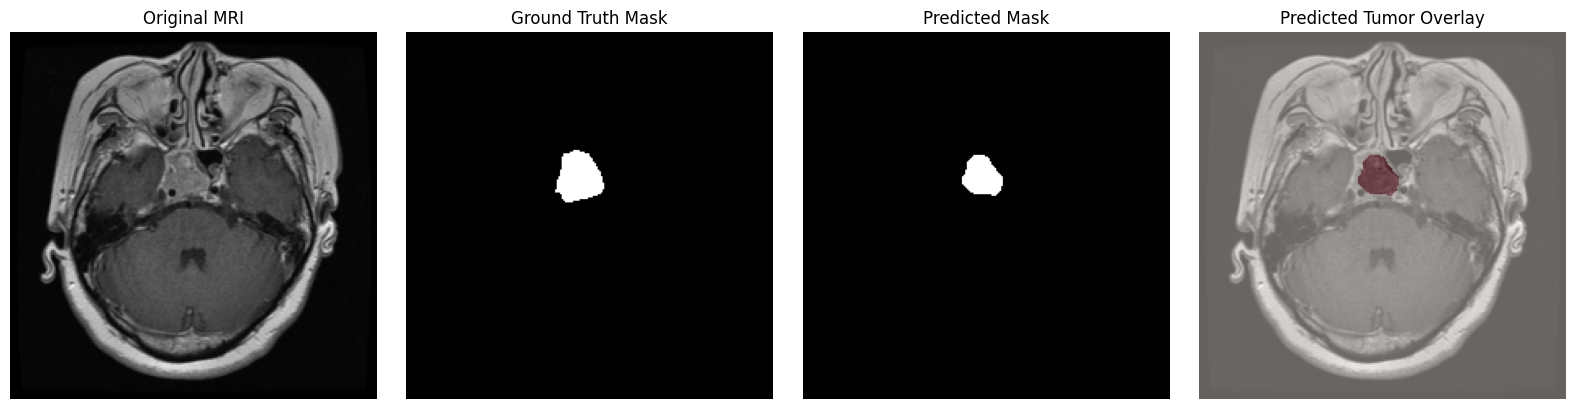

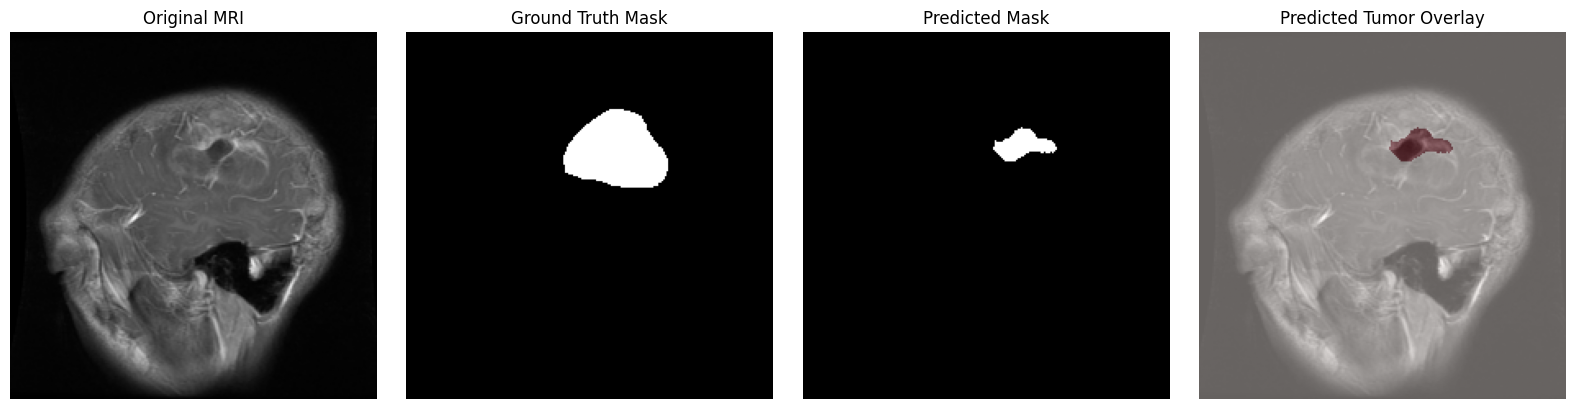

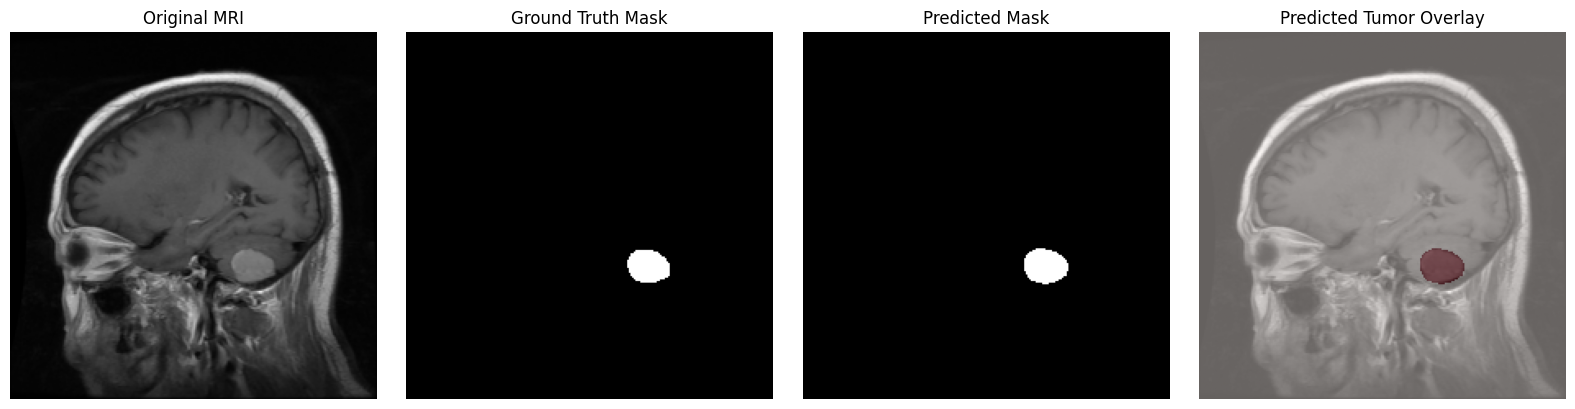

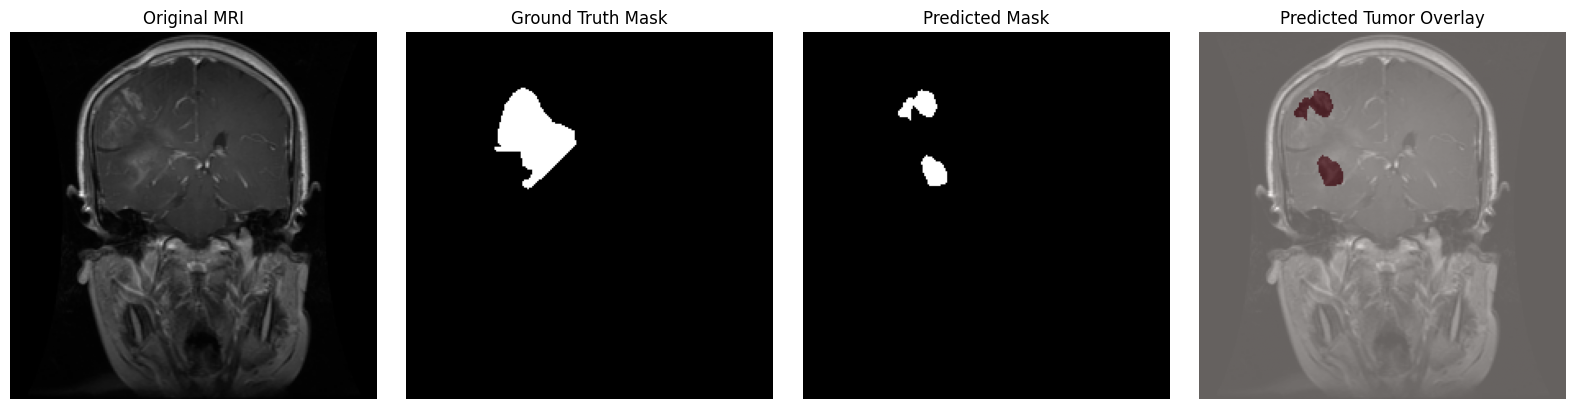

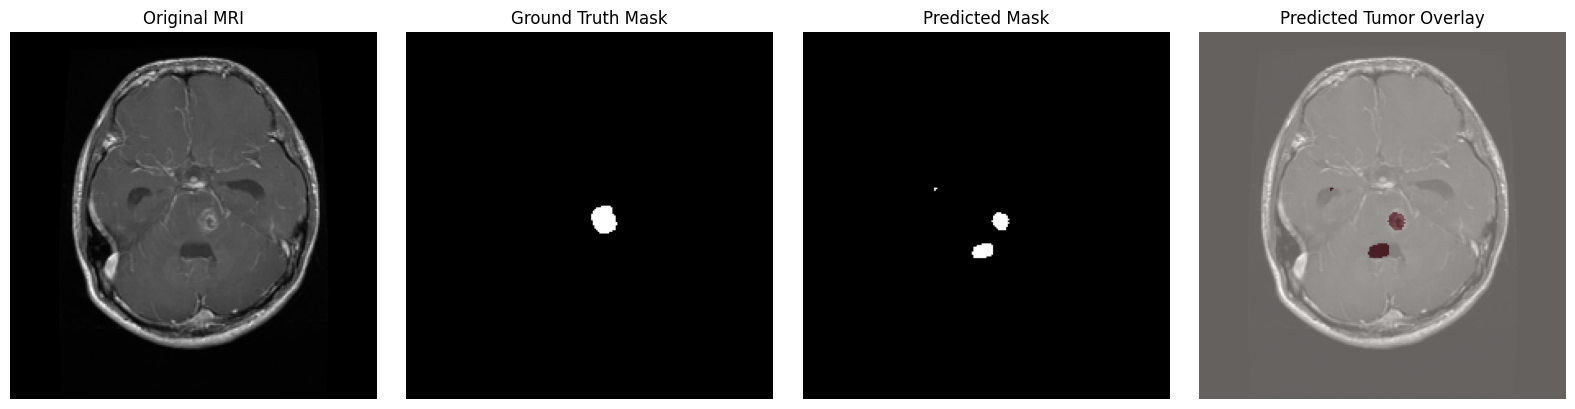

In [66]:
# Number of test samples to visualize
num_samples = 5

# Get one batch from the test dataset
test_images, test_masks = next(iter(test_dataset))

# Generate predictions
predictions = residual_unet.predict(test_images, verbose=0)

# Convert probability maps to binary masks
predicted_masks = (predictions > 0.5).astype(np.float32)

# Limit number of samples
num_samples = min(num_samples, len(test_images))

for i in range(num_samples):

    image = test_images[i].numpy().squeeze()
    true_mask = test_masks[i].numpy().squeeze()
    predicted_mask = predicted_masks[i].squeeze()

    # Create overlay
    overlay = np.stack([image, image, image], axis=-1)
    overlay[predicted_mask > 0] = [1, 0, 0]

    plt.figure(figsize=(16, 4))

    # Original MRI
    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original MRI")
    plt.axis("off")

    # Ground truth
    plt.subplot(1, 4, 2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    # Prediction
    plt.subplot(1, 4, 3)
    plt.imshow(predicted_mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    # Overlay
    plt.subplot(1, 4, 4)
    plt.imshow(image, cmap="gray")
    plt.imshow(predicted_mask, cmap="Reds", alpha=0.4)
    plt.title("Predicted Tumor Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### **Ground Truth vs Predicted Segmentation**

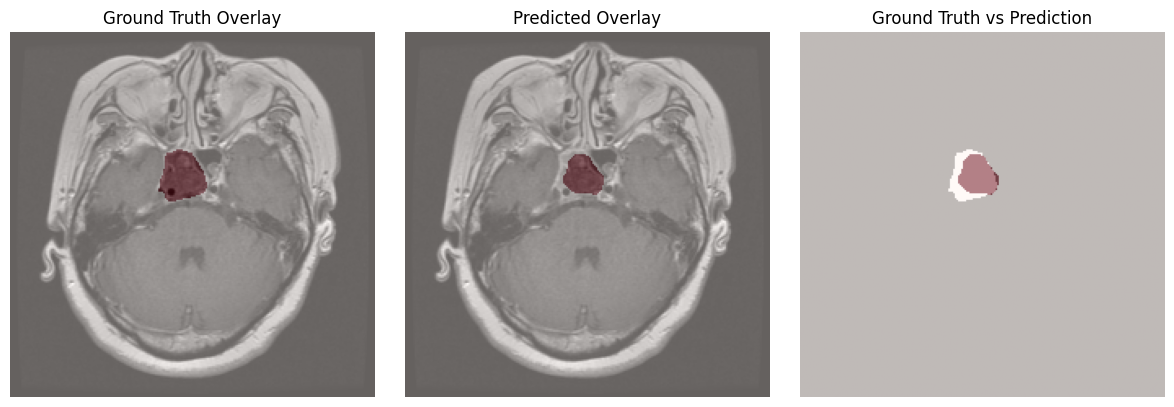

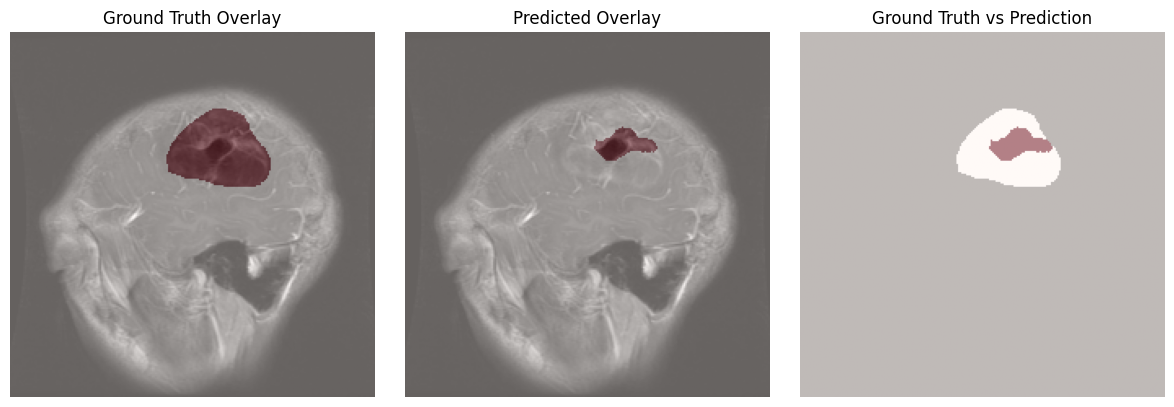

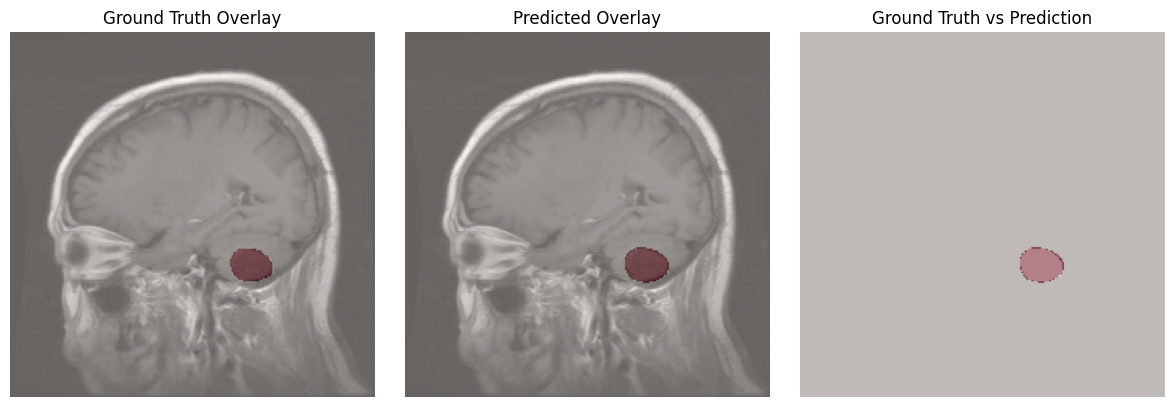

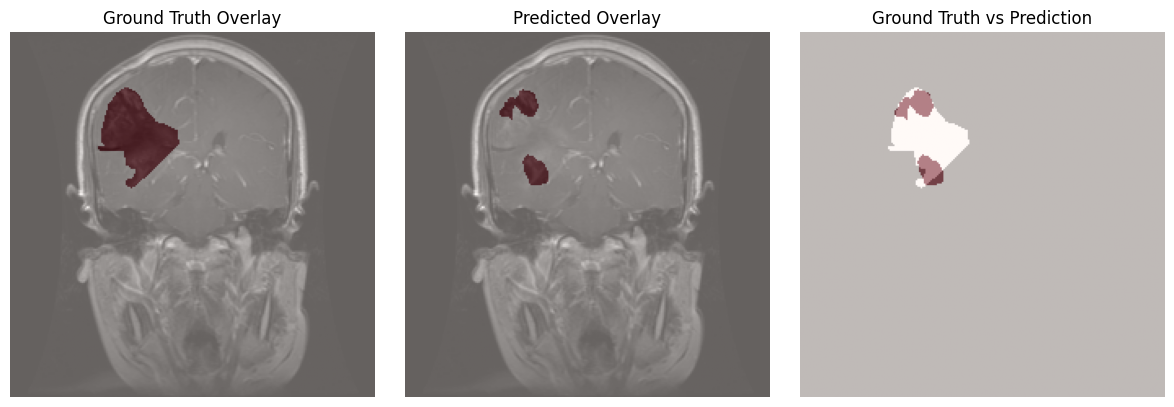

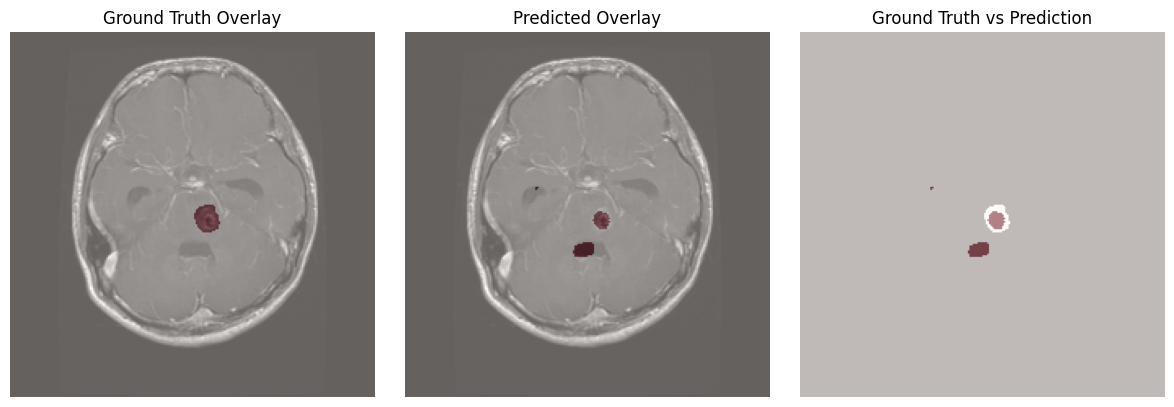

In [67]:
for i in range(num_samples):

    image = test_images[i].numpy().squeeze()
    true_mask = test_masks[i].numpy().squeeze()
    predicted_mask = predicted_masks[i].squeeze()

    plt.figure(figsize=(12, 4))

    # Ground truth overlay
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.imshow(true_mask, cmap="Reds", alpha=0.4)
    plt.title("Ground Truth Overlay")
    plt.axis("off")

    # Predicted overlay
    plt.subplot(1, 3, 2)
    plt.imshow(image, cmap="gray")
    plt.imshow(predicted_mask, cmap="Reds", alpha=0.4)
    plt.title("Predicted Overlay")
    plt.axis("off")

    # Difference
    plt.subplot(1, 3, 3)
    plt.imshow(true_mask, cmap="gray", alpha=0.5)
    plt.imshow(predicted_mask, cmap="Reds", alpha=0.5)
    plt.title("Ground Truth vs Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

## **Final Evaluation**

In [68]:
from sklearn.metrics import precision_score, recall_score

all_y_true = []
all_y_pred = []

for images, masks in test_dataset:
    predictions = residual_unet.predict(images, verbose=0)

    # Convert probabilities to binary masks
    predictions = (predictions > 0.5).astype("uint8")
    masks = masks.numpy().astype("uint8")

    all_y_true.extend(masks.flatten())
    all_y_pred.extend(predictions.flatten())

precision = precision_score(all_y_true, all_y_pred, zero_division=0)
recall = recall_score(all_y_true, all_y_pred, zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Precision: 0.8589
Recall:    0.7966


### **Save the Model**

In [70]:
residual_unet.save("brain_tumor_segmenter.keras")

print("Segmentation model saved successfully.")

Segmentation model saved successfully.
